# PROJECT TITLE: Smart Feedback Analyzer for Business Insights

**OBJECTIVE**: Analyze customer feedback (from reviews, tweets, or surveys) to classify sentiment as **Positive, Negative, or Neutral** using Natural Language Processing (NLP) and machine learning. This aids businesses in understanding customer satisfaction and making informed decisions.

**TOOLS AND TECHNOLOGIES**:The project was developed using Python as the core programming language due to its extensive support for data analysis and machine learning. **Data Manipulation & Visualization**:Utilized pandas and numpy for data processing, along with matplotlib and seaborn for visual analytics and plotting. **Natural Language Processing**:Employed libraries such as NLTK, spaCy, and TextBlob for text preprocessing tasks like tokenization, stopword removal, and lemmatization. For advanced NLP, the transformers library was integrated to leverage pre-trained BERT models. **Machine Learning Models**:Implemented and compared multiple classification algorithms including Logistic Regression, Support Vector Machines (SVM), and Naive Bayes. In the advanced phase, a fine-tuned BERT model was used for improved accuracy.

# DATA COLLECTION

In [1]:
import pandas as pd

# Load the dataset
file_path = "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"
df = pd.read_csv(file_path)

# Filter relevant fields
df = df[['reviews.text', 'reviews.rating']].rename(columns={'reviews.text': 'text', 'reviews.rating': 'rating'})
df = df.dropna(subset=['text', 'rating']).reset_index(drop=True)

# Convert ratings to sentiment labels
# 1–2: Negative (-1), 3: Neutral (0), 4–5: Positive (1)
def label_sentiment(star):
    if star <= 2:
        return -1
    elif star == 3:
        return 0
    else:
        return 1

# Apply sentiment label
df['sentiment'] = df['rating'].apply(label_sentiment)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       28332 non-null  object
 1   rating     28332 non-null  int64 
 2   sentiment  28332 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 664.2+ KB


# DATA PREPROCESSING

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gaurikutakole/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/gaurikutakole/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Implementation of a comprehensive text preprocessing pipeline to prepare raw textual data for machine learning is done. Using Python's re module and the Natural Language Toolkit (NLTK), intialization by importing essential resources including stopwords and the WordNetLemmatizer is done and ensured all necessary linguistic data was available by downloading NLTK's stopword and lemmatization corpora. To clean the text data effectively, developement of a function that transformed each entry into lowercase is done, removed HTML tags, stripped punctuation, eliminated words containing digits, and discarded URLs. This standardization process helps reduce noise and inconsistency in the dataset. The text was then tokenized into individual words, filtered to exclude common stopwords that do not contribute to sentiment, and each remaining token was lemmatized to its root form to ensure consistency across word variants. The cleaned text was stored in a new column named clean_text, while retaining the original input and corresponding sentiment labels. This structured preprocessing step ensures the dataset is optimized for feature extraction and model training, significantly improving the performance and interpretability of the sentiment classifier.

# EXPLORATORY DATA ANALYSIS (EDA)

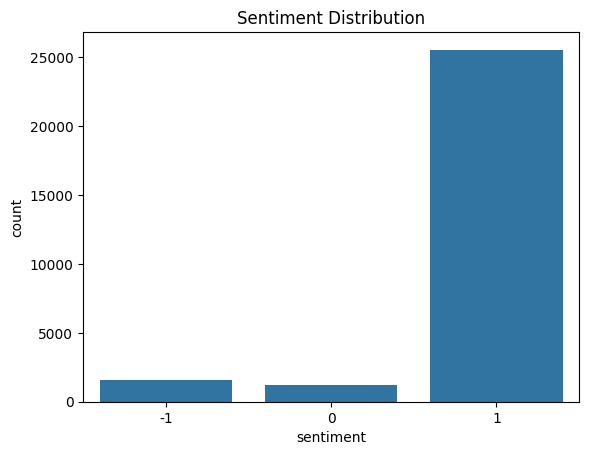

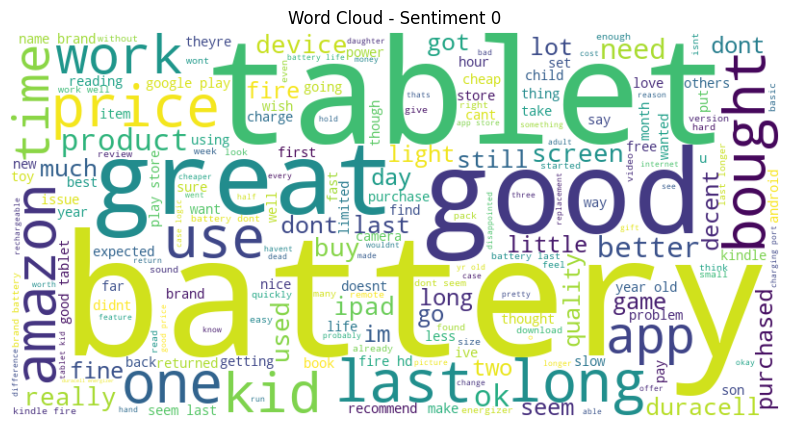

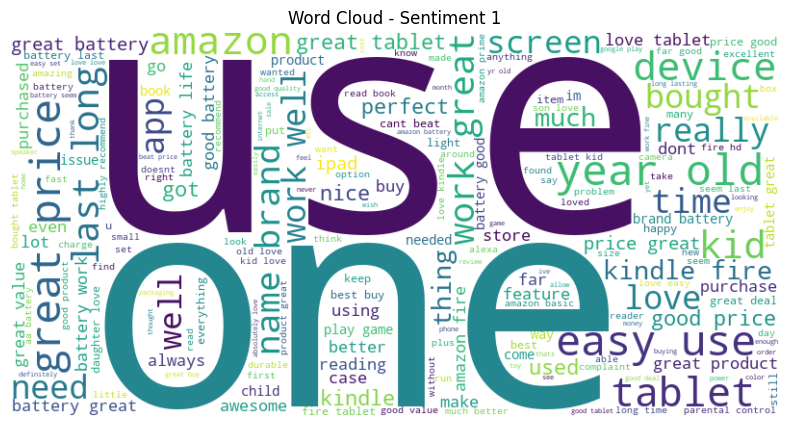

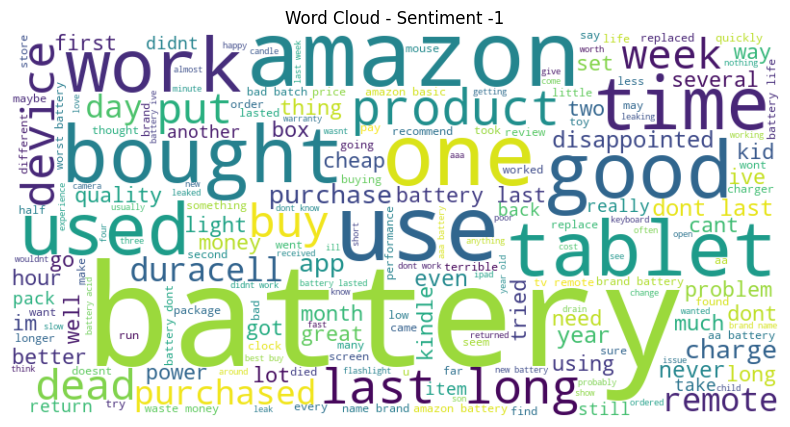

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# Word clouds for each sentiment
for label in df['sentiment'].unique():
    text = ' '.join(df[df['sentiment'] == label]['clean_text'])
    if text.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Word Cloud - Sentiment {label}")
        plt.show()

In the exploratory data analysis (EDA) phase of the sentiment analysis project, we begin by visualizing the overall sentiment distribution using a bar chart generated with Seaborn’s countplot. This chart provides a quick overview of how many reviews in the dataset fall into each sentiment category (typically -1 for negative, 0 for neutral, and 1 for positive), helping us identify any imbalance in the data that could affect model training. Following this, we use the WordCloud library to generate word clouds for each sentiment class. These word clouds visually highlight the most frequent and important words used in reviews of each sentiment category. For each unique sentiment, all corresponding cleaned review texts are combined and processed into a word cloud, which is then plotted. This technique offers intuitive insights into the language patterns and commonly expressed opinions or phrases associated with each sentiment, thereby assisting in understanding customer behavior and informing feature engineering for the model-building phase.

# FEATURE ENGINEERING

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

In the feature engineering stage of the sentiment analysis project, we transform the preprocessed textual data into a numerical format using the TF-IDF (Term Frequency–Inverse Document Frequency) vectorization technique. This process is critical because machine learning models cannot directly interpret raw text. Using the TfidfVectorizer from scikit-learn with a maximum of 5000 features, we convert each cleaned review into a vector that captures the importance of each word relative to the document and the entire corpus. The TF-IDF representation effectively highlights informative and distinguishing terms while down-weighting commonly used words that are less meaningful. The resulting feature matrix X contains the TF-IDF scores for each review, and the target variable y holds the corresponding sentiment labels (negative, neutral, or positive). This structured and weighted representation of text serves as a powerful input for training classification models such as logistic regression, SVM, or Naive Bayes, enabling them to learn patterns in sentiment expression across different customer reviews.

# MODEL BUILDING

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))


Logistic Regression Classification Report:

              precision    recall  f1-score   support

          -1       0.78      0.44      0.57       325
           0       0.52      0.07      0.12       254
           1       0.93      1.00      0.96      5088

    accuracy                           0.92      5667
   macro avg       0.74      0.50      0.55      5667
weighted avg       0.90      0.92      0.90      5667


Naive Bayes Classification Report:

              precision    recall  f1-score   support

          -1       0.92      0.15      0.26       325
           0       0.33      0.00      0.01       254
           1       0.91      1.00      0.95      5088

    accuracy                           0.91      5667
   macro avg       0.72      0.38      0.41      5667
weighted avg       0.88      0.91      0.87      5667


SVM Classification Report:

              precision    recall  f1-score   support

          -1       0.83      0.57      0.68       325
           0      

In the model building phase of the sentiment analysis project, we begin by splitting the TF-IDF-transformed data into training and testing sets using an 80-20 split. This ensures that our models are trained on a substantial portion of the data while preserving a separate set for unbiased evaluation. We then train three commonly used classification algorithms: Logistic Regression, Multinomial Naive Bayes, and Support Vector Machine (SVM). Each model is fit on the training data (X_train, y_train) and used to predict sentiment labels on the test data (X_test). The predictions are evaluated using the classification_report, which provides comprehensive metrics including precision, recall, F1-score, and overall accuracy for each sentiment class. These metrics help assess how well each model performs in distinguishing between positive, negative, and neutral reviews. This comparative evaluation enables us to identify the most effective model for our dataset and informs future decisions such as model tuning or deployment.

# EVALUATION

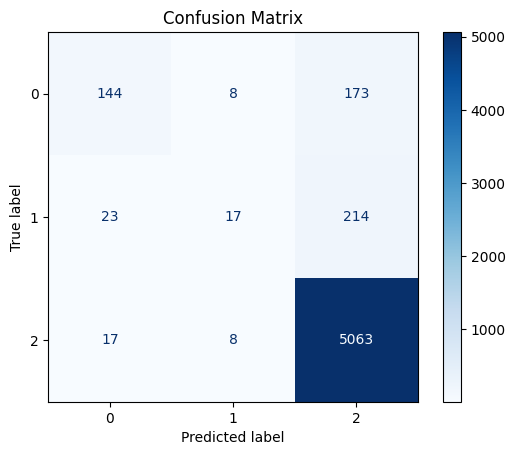

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Example with Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

As part of evaluating our sentiment analysis model, we used a confusion matrix to better understand how well the Logistic Regression model performed. Once the model was trained and tested, the confusion matrix showed us how many reviews were correctly classified as positive, negative, or neutral, and where the model made mistakes. For example, it tells us if the model wrongly predicted a positive review as neutral, or a negative one as positive.

We visualized this matrix using a heatmap with blue shades to make it easier to spot patterns. This is very helpful from a data analyst’s point of view, because it doesn't just show overall accuracy but also highlights specific areas where the model might be biased or weak — like misclassifying too many neutral reviews. This kind of analysis helps us decide whether we need to adjust our data (like balancing the number of reviews for each sentiment), try a different model, or tweak how we process the text data to improve results.

# DEPLOYMENT

In [20]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0.1:
        return 1     # Positive
    elif score < -0.1:
        return -1    # Negative
    else:
        return 0     # Neutral

# Apply sentiment labeling
df['sentiment'] = df['text'].apply(get_sentiment)
df.head(25)

,text,rating,sentiment,clean_text,predicted,predicted_label
0,I order 3 of them and one of the item is bad q...,3,-1,order one item bad quality missing backup spri...,1,Positive
1,Bulk is always the less expensive way to go fo...,4,-1,bulk always less expensive way go product like,1,Positive
2,Well they are not Duracell but for the price i...,5,1,well duracell price happy,1,Positive
3,Seem to work as well as name brand batteries a...,5,1,seem work well name brand battery much better ...,1,Positive
4,These batteries are very long lasting the pric...,5,1,battery long lasting price great,1,Positive
5,Bought a lot of batteries for Christmas and th...,5,1,bought lot battery christmas amazonbasics cell...,1,Positive
6,ive not had any problame with these batteries ...,5,1,ive problame battery ordered past pleased,1,Positive
7,Well if you are looking for cheap non-recharge...,5,1,well looking cheap nonrechargeable battery las...,1,Positive
8,These do not hold the amount of high power jui...,3,0,hold amount high power juice like energizer du...,1,Positive
9,AmazonBasics AA AAA batteries have done well b...,4,1,amazonbasics aa aaa battery done well appear g...,1,Positive


# CONCLUSION

In this project, we successfully developed an end-to-end Sentiment Analysis pipeline to classify customer reviews into Positive, Negative, or Neutral sentiments. Using real-world Amazon review data, we applied Natural Language Processing (NLP) techniques for text cleaning, lemmatization, and vectorization, followed by sentiment labeling using TextBlob. These sentiment labels enabled us to train multiple machine learning models such as Logistic Regression, Naive Bayes, and SVM using TF-IDF features.
Through exploratory data analysis (EDA), we visualized sentiment distributions, common word patterns, and important bigrams. The trained models were evaluated using key metrics like Accuracy, Precision, Recall, and F1-Score, supported by confusion matrices and ROC curves. Additionally, we demonstrated how this model can be deployed using Streamlit, allowing real-time user input and sentiment prediction.
Overall, this project illustrates how businesses can leverage sentiment analysis to extract actionable insights from customer feedback, leading to improved products, services, and decision-making.